# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

### Dataset

In [2]:
df = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")
df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


### Task #1: Visualization and 1st step toward the CAPM

Daily returns

In [14]:
daily_returns = df.pct_change()
daily_returns = df.pct_change() * 100
daily_returns = daily_returns.iloc[1:]
daily_returns.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-13,-0.374946,-1.205144,-0.166006,1.813685,1.415339,-0.769869,-19.327430,-0.738516,-0.494792
2012-01-17,1.164812,0.857909,0.598603,-0.809717,1.815943,0.468852,16.717854,0.574410,0.355295
2012-01-18,1.038382,-0.239234,0.264463,3.918367,4.282725,0.594448,0.789470,0.688856,1.110793
2012-01-19,-0.316937,0.666134,0.296736,0.549882,2.644634,-0.303752,-0.186494,1.052283,0.493866
2012-01-20,-1.741670,-0.052939,0.295858,-1.250000,-1.810236,4.431642,-0.597907,-8.377507,0.066946


Scatter Plots of daily returns against the market daily returns

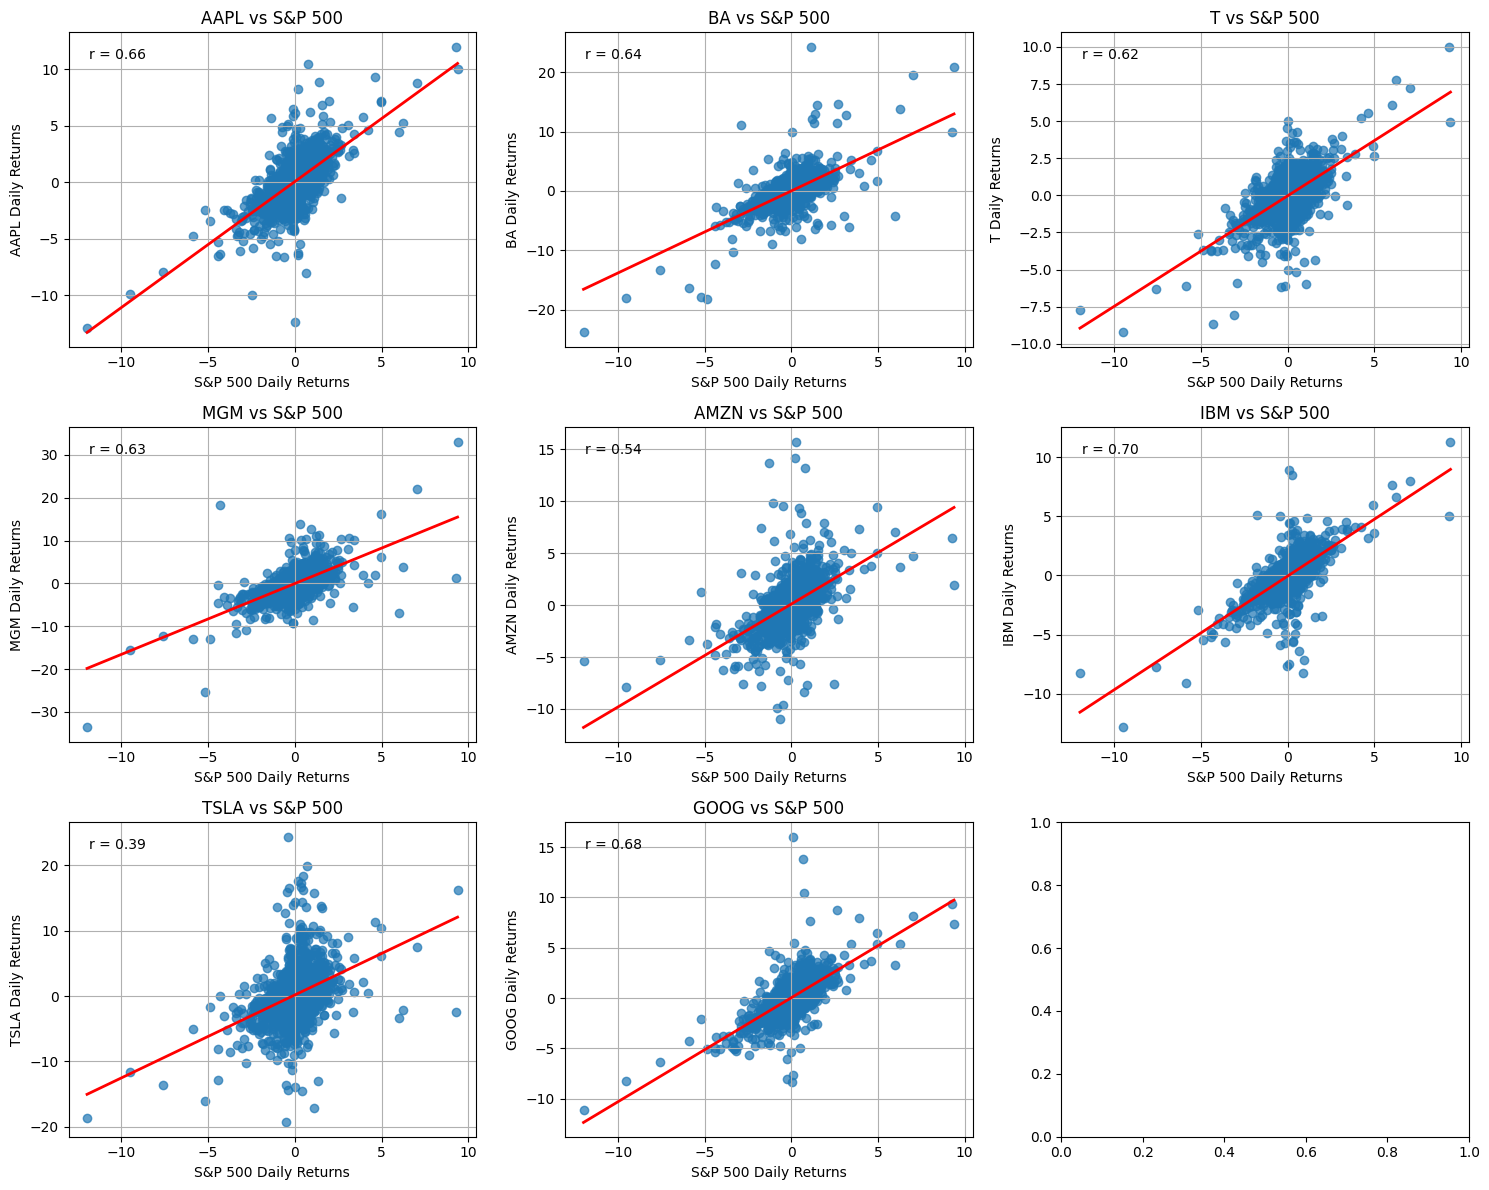

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(daily_returns.columns):
    if col != "sp500":
        ax = axes[i]

        x = daily_returns["sp500"].to_numpy(dtype=float)
        y = daily_returns[col].to_numpy(dtype=float)

        # finite mask
        mask = np.isfinite(x) & np.isfinite(y)
        x_f, y_f = x[mask], y[mask]

        # scatter
        ax.scatter(x_f, y_f, alpha=0.7)

        if x_f.size >= 2 and np.ptp(x_f) > 0:
            # regression line
            m, b = np.polyfit(x_f, y_f, 1)
            x_line = np.linspace(x_f.min(), x_f.max(), 100)
            ax.plot(x_line, m * x_line + b, color="red", linewidth=2)

            # correlation coefficient
            r = np.corrcoef(x_f, y_f)[0, 1]
            ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
                    fontsize=10, verticalalignment="top")

        ax.set_xlabel("S&P 500 Daily Returns")
        ax.set_ylabel(f"{col} Daily Returns")
        ax.set_title(f"{col} vs S&P 500")
        ax.grid(True)

plt.tight_layout()
plt.show()

For the majority of the stocks, the correlation of the daily returns with the benchmark (S&P 500) is relatively strong, especially for Google, Apple and IBM where the correlation is greater than 0.65.

The above-mentioned companies play a crucial role in the S&P 500 index, therefore changes in returns for each of the stocks individually, impact the changes of the market daily returns.

### Task #2: Compute alpha and beta

Apply the CAPM : run an OLS regression of stock i returns on market returns, over the whole period. Assume rf = 0. Are the estimates significant?

In [ ]:
capm_results = []

for col in daily_returns.columns:
    if col != "sp500":
        y = daily_returns[col]
        X = sm.add_constant(daily_returns["sp500"])  # adds alpha
        model = sm.OLS(y, X).fit()

        alpha, beta = model.params  # extract coefficients
        p_alpha, p_beta = model.pvalues  # significance levels

        capm_results.append({
            "Stock": col,
            "Alpha": alpha,
            "Beta": beta,
            "Alpha_pval": p_alpha,
            "Beta_pval": p_beta,
            "R2": model.rsquared
        })


capm_df = pd.DataFrame(capm_results)

print(capm_df)

  Stock     Alpha      Beta  Alpha_pval      Beta_pval        R2
0  AAPL  0.052837  1.112891    0.067202  3.521164e-267  0.432070
1    BA -0.002292  1.382867    0.951096  7.299279e-251  0.411941
2     T -0.028577  0.744630    0.182942  4.892378e-227  0.381261
3   MGM -0.016893  1.653568    0.712986  1.874186e-240  0.398728
4  AMZN  0.102261  0.991732    0.003512  2.611172e-163  0.291125
5   IBM -0.053480  0.960416    0.014747  1.185758e-322  0.495525
6  TSLA  0.175917  1.268611    0.009920   1.965135e-78  0.150482
7  GOOG  0.033371  1.034881    0.180655  2.345742e-298  0.468638


Based on the values of the p-value, the Beta coefficients are all statistically significant. For the majority of OLS regressions, the Alpha is statistically equal to 0, as required. This is however violated for Amazon, IBM and Tesla (p-value < 0.05). 

Plot the beta and alpha for the 8 stocks. Which stock has the highest (lowest) beta and alpha? Comment!

Use the observed returns and the predicted ones to compute and plot the histogram of error terms εi for each stock. Comment!

Your boss wants to take a lot of risk to deliver high return. He asks you to (i) select the 4 riskier assets (over the full period), (ii) form an equally weighted portfolio, and (iii) to estimate the portfolio return based on parameters (β and rm) estimated above.

### Task #3 : Testing the CAPM theory

 For each year : compute βy−1
 i
 year y −1 (OLS regression)
 over 252 business days at the end of each

At the end or year y, compare the average return of the stock ¯ry
 i
 (annualized) to the one predicted by the CAPM model ˆry
 M (using βy−1
 i
 measured at y −1 but the average market return ¯ry
 M measured at y).

Generate the scatter plot of the realized returns against the beta or find
 innovative ways to plot you results.

Alternatively, you may use a β computed over longer (shorter) periods of
 time.

Comment your results in the light of yesterday’s lecture : try to give as
 much economic interpretation as you can!

### Optional Task : Obtain data from the web

Web-scrapping : get the list of S&P 500 tickers from Wikipedia

Use the list of tickers as input in the yfinance package (an API that gives
 access to Yahoo Finance data)

 Describe and comment the data. Why do you have more variables than in the
 PCLab_Data.xlsx file?